# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

In [59]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

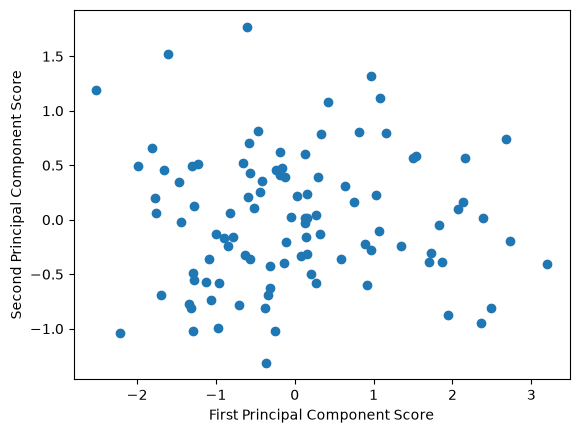

In [60]:
np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

Advantages: 
- It compresses 3 variables into 2 while keeping ~99% of the variance (80%+19%)
- It correctly isolates the one non-redundant piece of information (ser3's deviation) as its own axis — an outlier that isn't obvious from any single histogram.

Disadvantages: 
- The axes are abstract linear combinations, not directly interpretable without going back to the loadings
- It silently discards the ser1-vs-ser2 distinction (into PC3) since that information carries almost no variance
- It can't show you the actual functional relationships (the tight linear ser1-ser2 relationship, the looser ser1/ser2-ser3 relationship) that the pairplot makes immediately visual.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

## Dataset 1: Ransomware

### Setup

In [61]:
pd.set_option('display.max_columns', 100)

In [ ]:
# Load and combine the datasets
files = [
    "malware_benign_06162017_1.csv",
    "malware_benign_06162017_2.csv",
    "malware_benign_06162017_3.csv",
    "malware_benign_06162017_4.csv",
    "malware_benign_06162017_5.csv",
    "malware_benign_06162017_6.csv",
    "malware_benign_06162017_7.csv",
    "malware_benign_06162017_8.csv",
    "malware_benign_06162017_9.csv",
    "malware_benign_06162017_10.csv",
    "malware_benign_06162017_11.csv",
    "malware_benign_06162017_12.csv",
    "ransomware_wannalocker_08212017_1.csv",
    "ransomware_wannalocker_08212017_2.csv",
    "ransomware_wannalocker_08212017_3.csv"
]

dfs = []
for f in files:
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()  # source CSVs have inconsistent leading spaces in headers
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(data.shape)

(12968, 85)


In [66]:
# Print the dataset
data.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,0,1,0,0,0,0,1.0,403.642857,179.333333,571.875000,200,0,0,0,0,0,0,6,1076,8,4575,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,349,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,65902.578797,5730.659026,349.000000,0.000000,349.0,349.0,349.0,349.0,0.000000,349.0,349.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,5730.659026,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1594,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16/06/2017 03:55:52,119,2,0,23.0,0.0,23.0,0.0,11.500000,16.263456,0.0,0.0,0.000000,0.000000,193277.310924,16806.722689,119.000000,0.000000,119.0,119.0,119.0,119.0,0.000000,119.0,119.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,64,0,16806.722689,0.000000,0.0,23.0,15.333333,13.279056,176.333333,0,1,0,0,1,0,0,0,0.0,23.000000,11.500000,0.000000,64,0,0,0,0,0,0,2,23,0,0,1486,-1,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16/06/2017 03:55:53,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,1,0,0,1,0,0,0,1.0,31.000000,31.000000,0.000000,32,0,0,0,0,0,0,1,31,1,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16/06/2017 03:55:58,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,0,1,0,0,0,0,1.0,124.615385,218.833333,43.857143,200,0,0,0,0,0,0,6,1313,7,307,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [67]:
# Binarize the Label column

print("Before:", data['Label'].unique())

data['Label'] = np.where(data['Label'].str.strip().str.upper() == 'BENIGN', 0, 1)

print("After:", data['Label'].unique())
data['Label'].value_counts()

Before: <StringArray>
['BENIGN', 'RANSOMWARE_WANNALOCKER']
Length: 2, dtype: str
After: [0 1]


Label
1    10161
0     2807
Name: count, dtype: int64

In [68]:
# Drop duplicate rows
before = len(data)
data = data.drop_duplicates()
print(f"Dropped {before - len(data)} duplicate rows -> {len(data)} rows remaining")

Dropped 0 duplicate rows -> 12968 rows remaining


In [69]:
# Drop null & NaN values
before = len(data)
data = data.dropna()  # covers both nulls and NaNs
print(f"Dropped {before - len(data)} rows with null/NaN values -> {len(data)} rows remaining")

Dropped 0 rows with null/NaN values -> 12968 rows remaining


In [70]:
# Drop negative values
before = len(data)
numeric_cols = data.select_dtypes(include=[np.number]).columns
negative_mask = (data[numeric_cols] < 0).any(axis=1)
data = data[~negative_mask]
print(f"Dropped {before - len(data)} rows containing negative values -> {len(data)} rows remaining")

Dropped 6261 rows containing negative values -> 6707 rows remaining


In [71]:
# Drop non-numeric columns
non_numeric_cols = data.select_dtypes(exclude=[np.number]).columns.tolist()
print("Dropping non-numeric columns:", non_numeric_cols)

data = data.drop(columns=non_numeric_cols)
print(data.shape)

Dropping non-numeric columns: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
(6707, 81)


In [73]:
# Print cleaned DataFrame
data.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,51023,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,321.621931,1418.0,0.0,571.875000,679.532284,37410.462484,92.682087,11619.538462,14541.155884,49105.0,24.0,101887.0,20377.4,12821.550737,30425.0,111.0,128516.0,18359.428571,24038.557859,54822.0,24.0,0,0,0,0,200,264,39.720895,52.961193,0.0,1418.0,376.733333,562.514948,316423.066667,0,0,0,1,0,0,0,0,1.0,403.642857,179.333333,571.875000,200,0,0,0,0,0,0,6,1076,8,4575,65535,353,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,55509,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,0.000000,0.0,0.0,0.000000,0.000000,836.594252,53.973823,37055.000000,0.000000,37055.0,37055.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,32,32,26.986911,26.986911,0.0,31.0,20.666667,17.897858,320.333333,0,1,0,0,1,0,0,0,1.0,31.000000,31.000000,0.000000,32,0,0,0,0,0,0,1,31,1,0,1548,391,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,44852,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,331.306152,168.0,0.0,43.857143,75.366722,9064.103353,72.736632,14893.916667,18532.640750,62243.0,55.0,125550.0,25110.0,28468.232023,70464.0,172.0,156011.0,26001.833333,24955.901822,67743.0,55.0,0,0,0,0,200,232,33.570753,39.165879,0.0,753.0,115.714286,231.422833,53556.527473,0,0,0,1,0,0,0,0,1.0,124.615385,218.833333,43.857143,200,0,0,0,0,0,0,6,1313,7,307,65535,352,3,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,43492,443,6,35978,1,2,0.0,31.0,0.0,0.0,0.000000,0.000000,31.0,0.0,15.500000,21.920310,861.637667,83.384290,17989.000000,25362.506028,35923.0,55.0,0.0,0.0,0.000000,0.0,0.0,55.0,55.000000,0.000000,55.0,55.0,0,0,0,0,32,64,27.794763,55.589527,0.0,31.0,7.750000,15.500000,240.250000,0,0,0,0,1,1,0,0,2.0,10.333333,0.000000,15.500000,32,0,0,0,0,0,0,1,0,2,31,1550,122,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
9,51656,443,6,37591,1,1,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,53.204224,37591.000000,0.000000,37591.0,37591.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,32,32,26.602112,26.602112,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1.0,0.000000,0.000000,0.000000,32,0,0,0,0,0,0,1,0,1,0,1594,350,0,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [75]:
# Sanity check

print("Any nulls left:", data.isnull().values.any())
print("Any negatives left:", (data < 0).values.any())
print("Any duplicate rows left:", data.duplicated().any())
print("All columns numeric:", all(np.issubdtype(dt, np.number) for dt in data.dtypes))
print("\nFinal shape:", data.shape)
print("\nLabel counts:")
print(data['Label'].value_counts())

Any nulls left: False
Any negatives left: False
Any duplicate rows left: False
All columns numeric: True

Final shape: (6707, 81)

Label counts:
Label
1    5270
0    1437
Name: count, dtype: int64


In [43]:
# Export cleaned data to CSV
data.to_csv("combined_clean.csv", index=False)
print("Saved combined_clean.csv")

Saved combined_clean.csv


### Heatmaps

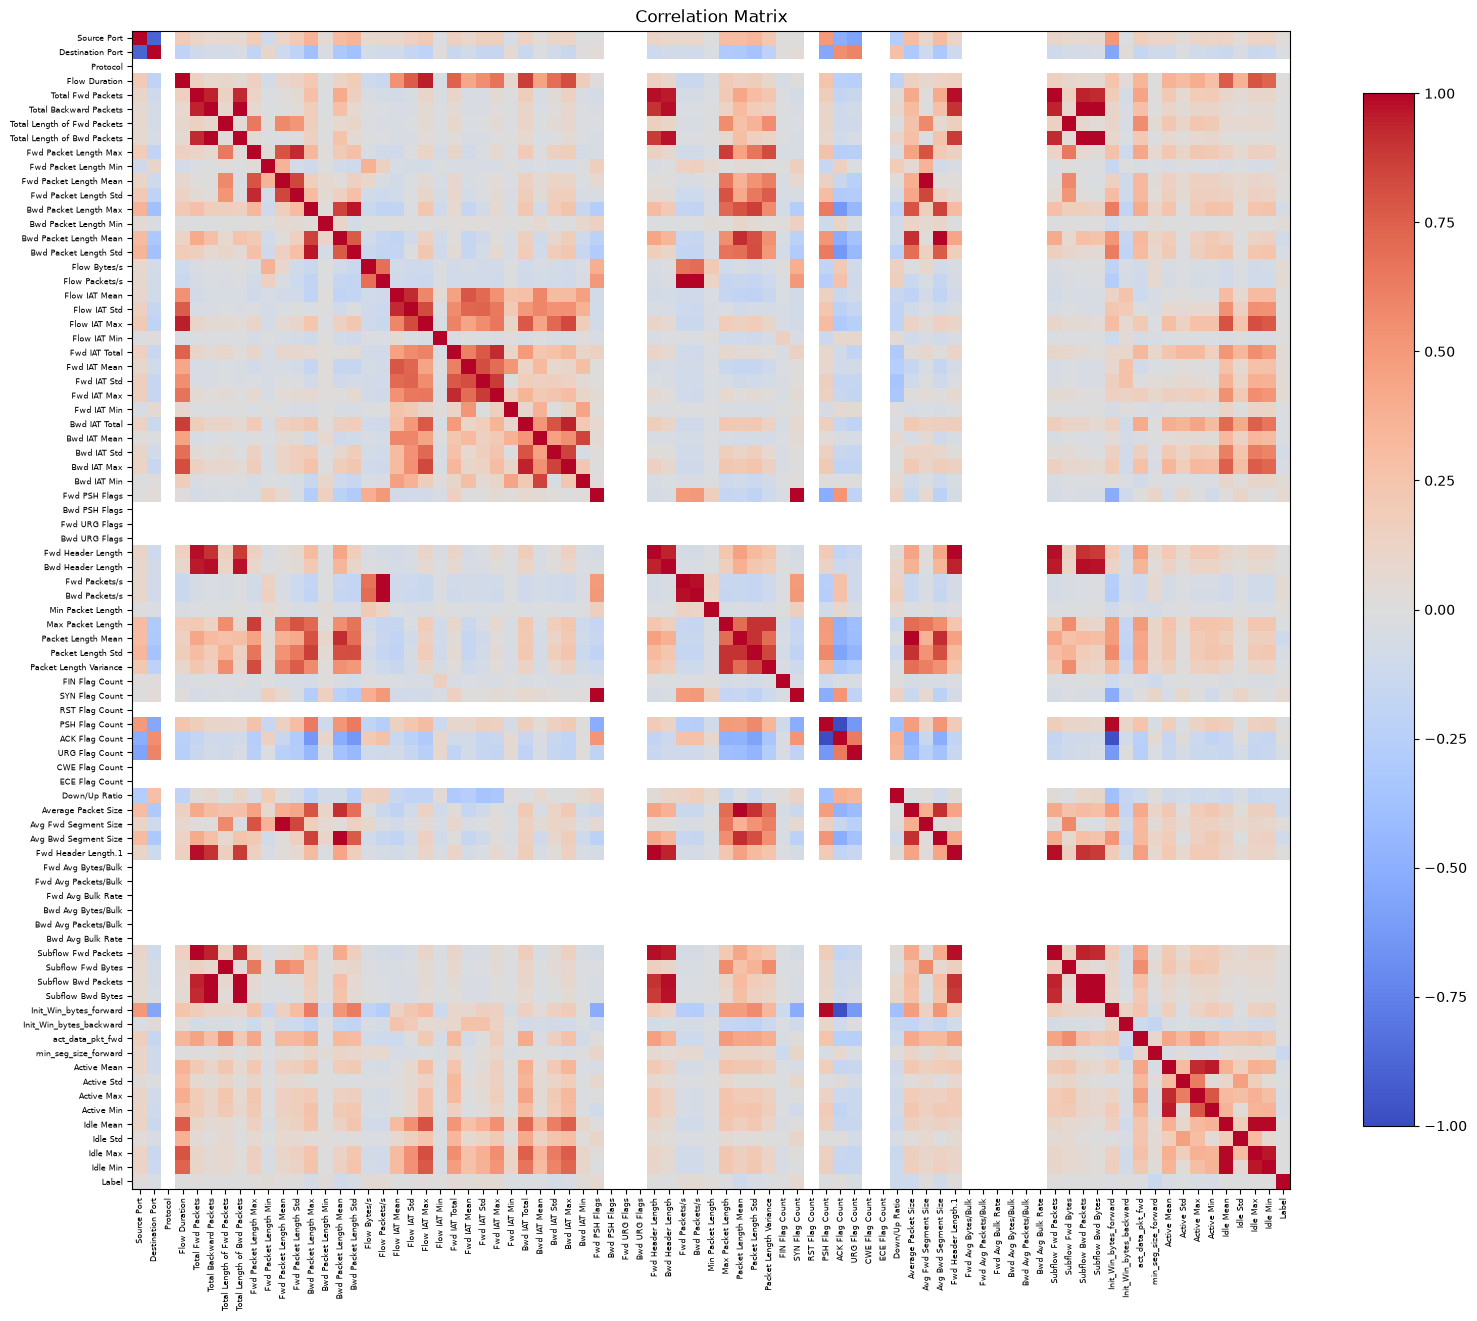

In [44]:
# Draw heatmaps

# Correlation
corr = data.corr()

# Plot
fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticklabels(corr.columns, fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150)
plt.show()

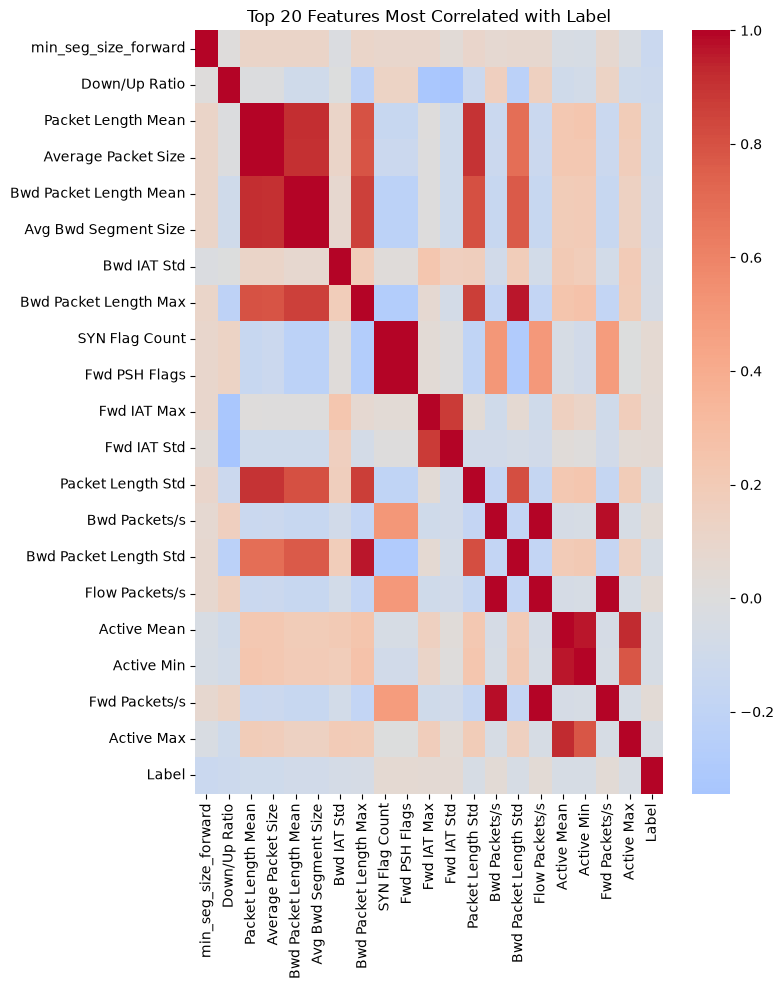

min_seg_size_forward     -0.129788
Down/Up Ratio            -0.115157
Packet Length Mean       -0.105000
Average Packet Size      -0.101978
Bwd Packet Length Mean   -0.084860
Avg Bwd Segment Size     -0.084860
Bwd IAT Std              -0.070080
Bwd Packet Length Max    -0.058530
SYN Flag Count            0.057997
Fwd PSH Flags             0.057997
Fwd IAT Max               0.051340
Fwd IAT Std               0.050051
Packet Length Std        -0.049976
Bwd Packets/s             0.049421
Bwd Packet Length Std    -0.048792
Flow Packets/s            0.047809
Active Mean              -0.047742
Active Min               -0.047733
Fwd Packets/s             0.045514
Active Max               -0.043198
Name: Label, dtype: float64

In [47]:
# More readable: top features most correlated with Label
label_corr = corr['Label'].drop('Label').sort_values(key=lambda s: s.abs(), ascending=False)
top_n = 20
top_features = label_corr.head(top_n).index.tolist()

plt.figure(figsize=(8, 10))
sns.heatmap(data[top_features + ['Label']].corr(), cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True)
plt.title(f"Top {top_n} Features Most Correlated with Label")
plt.tight_layout()
plt.show()

label_corr.head(top_n)

### Principal Component Analysis (PCA)

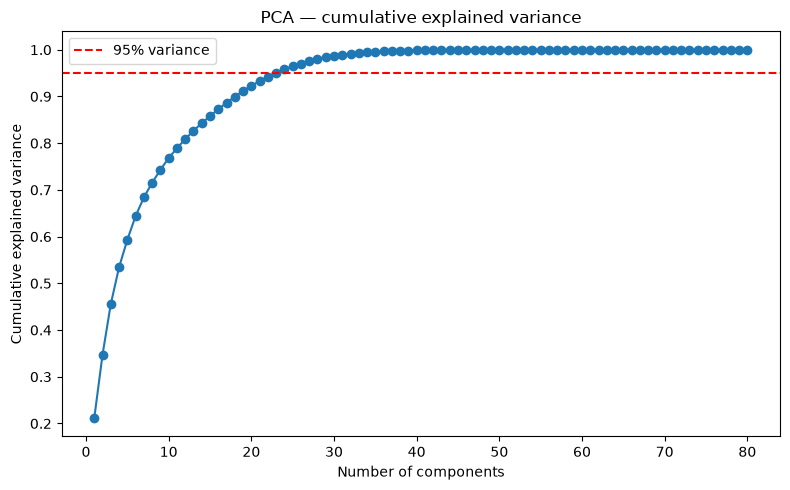

Components needed to explain 95% variance: 23 / 80


In [48]:
# Principal Component Analysis (standardized features)

X = data.drop(columns=['Label'])
y = data['Label']

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cumulative) + 1), cumulative, marker='o')
ax.axhline(0.95, color='red', linestyle='--', label='95% variance')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — cumulative explained variance')
ax.legend()
plt.tight_layout()
plt.savefig("pca_explained_variance.png", dpi=150)
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95) + 1)
print(f"Components needed to explain 95% variance: {n_components_95} / {X.shape[1]}")

### Bubbleplots

In [50]:
# Draw bubbleplots (PCA based)
# Using the first 3 principal components as plot axes (PC1/PC2/PC3), with bubble size mapped 
# to a chosen raw feature and color mapped to `Label` (benign vs. ransomware).

pcs = pca.transform(X_scaled)
pc_df = pd.DataFrame(pcs[:, :3], columns=['PC1', 'PC2', 'PC3'], index=X.index)

def scaled_size(series, low=20, high=800):
    s = (series - series.min()) / (series.max() - series.min())
    return s * (high - low) + low

label_colors = y.map({0: 'tab:blue', 1: 'tab:red'})
label_names = {0: 'BENIGN', 1: 'RANSOMWARE_WANNALOCKER'}

In [51]:
def bubble_plot(x_col, y_col, size_col, title, filename):
    fig, ax = plt.subplots(figsize=(9, 7))
    sizes = scaled_size(X[size_col])
    for lbl, color in [(0, 'tab:blue'), (1, 'tab:red')]:
        mask = (y == lbl)
        ax.scatter(pc_df.loc[mask, x_col], pc_df.loc[mask, y_col],
                   s=sizes[mask], c=color, alpha=0.5, edgecolors='k', linewidths=0.3,
                   label=label_names[lbl])
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{title}\n(bubble size = {size_col})")
    ax.legend(title='Label', markerscale=0.5)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

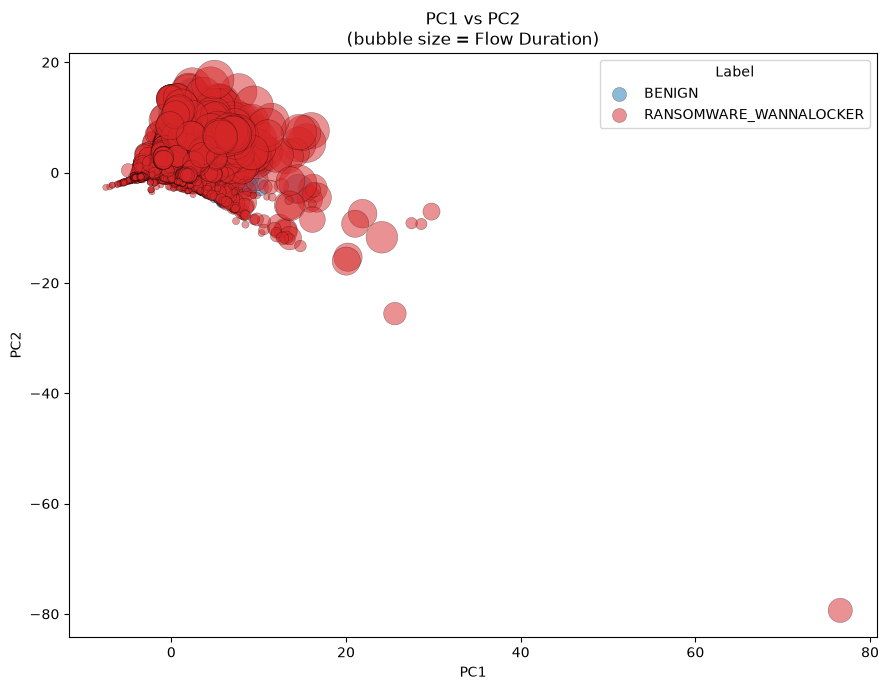

In [52]:
# Bubbleplot for Flow Duration
bubble_plot('PC1', 'PC2', 'Flow Duration', 'PC1 vs PC2', 'bubble_pc1_pc2_flowduration.png')

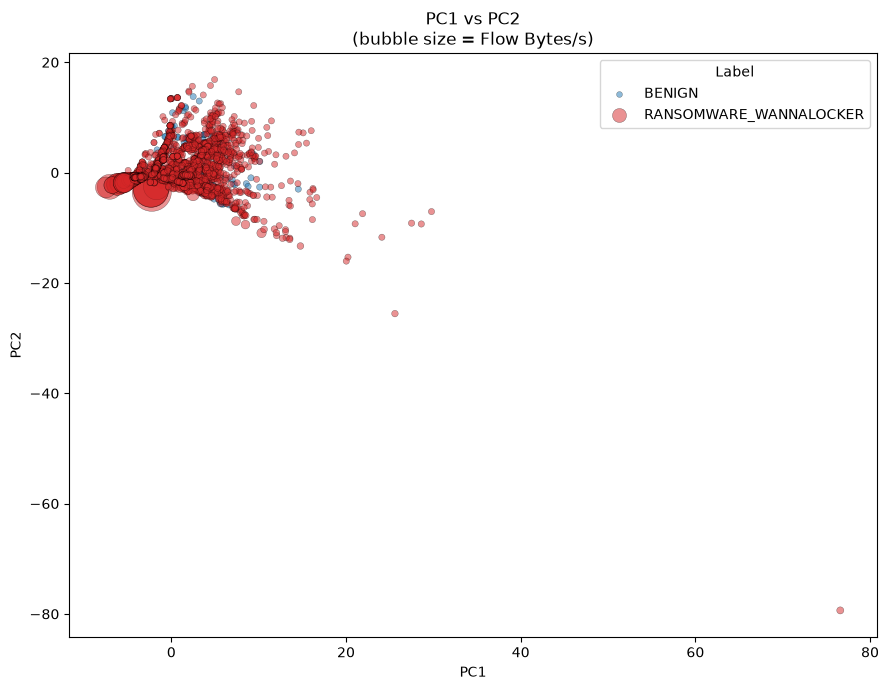

In [53]:
# Bubbleplot for Flow Bytes/s
bubble_plot('PC1', 'PC2', 'Flow Bytes/s', 'PC1 vs PC2', 'bubble_pc1_pc2_flowbytes.png')

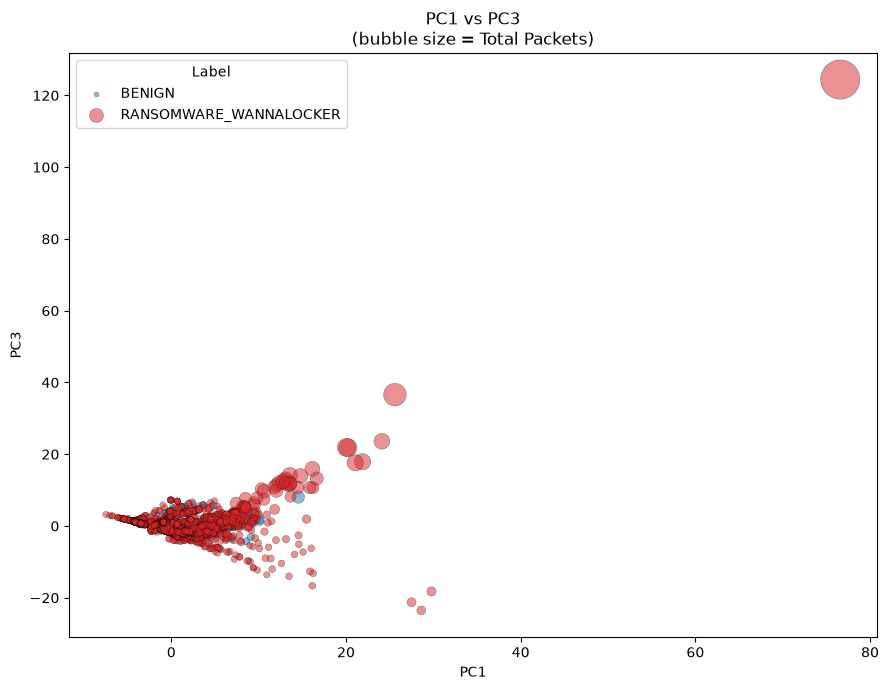

In [54]:
# Bubbleplot for Total Packets
X['Total Packets'] = X['Total Fwd Packets'] + X['Total Backward Packets']
bubble_plot('PC1', 'PC3', 'Total Packets', 'PC1 vs PC3', 'bubble_pc1_pc3_totalpackets.png')

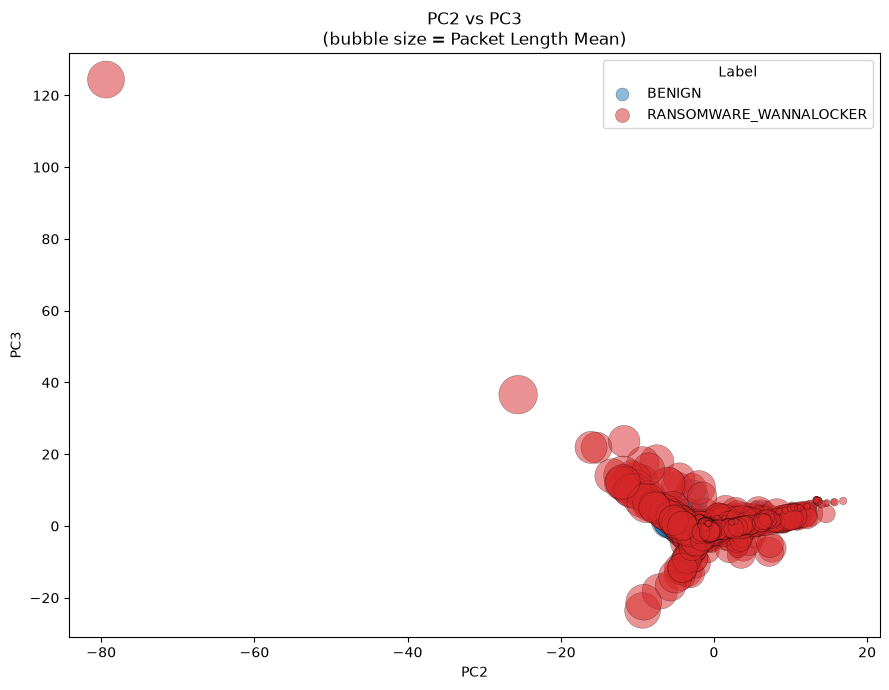

In [55]:
# Bubbleplot for Packet Length Mean
bubble_plot('PC2', 'PC3', 'Packet Length Mean', 'PC2 vs PC3', 'bubble_pc2_pc3_packetlen.png')

### Regression Analysis

#### Linear Regression

In [ ]:
# Linear Regression Analysis

# Training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

In [ ]:
# Calculate teh R^2 and RMSE
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)

print(f"R^2: {r2_score(y_test, y_pred_lin):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_lin) ** 0.5:.4f}")

# Accuracy if we threshold the continuous output at 0.5 to force a class decision
y_pred_lin_class = (y_pred_lin >= 0.5).astype(int)
print(f"Accuracy (0.5 threshold on linear output): {accuracy_score(y_test, y_pred_lin_class):.4f}")

In [ ]:
# Create Coefficient DataFrame & print
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lin_reg.coef_
}).sort_values('coefficient', key=abs, ascending=False)

coef_df.head(15)

In [ ]:
# Plot the Regression
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_lin, alpha=0.3, s=15)
ax.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
ax.set_xlabel('Actual Label')
ax.set_ylabel('Predicted (continuous)')
ax.set_title('Linear Regression: Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.savefig('linreg_predicted_vs_actual.png', dpi=150)
plt.show()

#### Logistic Regression

In [ ]:
# Logistic Regression

# Setup
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_log):.4f}")
print()
print(classification_report(y_test, y_pred_log, target_names=['BENIGN', 'RANSOMWARE_WANNALOCKER']))

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['BENIGN', 'RANSOMWARE'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['BENIGN', 'RANSOMWARE'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig('logreg_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_log)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba_log):.3f}")
ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('logreg_roc_curve.png', dpi=150)
plt.show()

#### Summary

Compare `r2_score` / thresholded accuracy from the linear model against the logistic model's accuracy and ROC-AUC above. In general, the logistic model's accuracy and AUC are the more trustworthy numbers for this binary classification problem — the linear regression is included because it was requested, but its R² and coefficients should be read as a descriptive linear association with Label rather than as a proper probability model.

## Dataset 2: Misinformation

### Setup

### Heatmaps

### Principal Component Analysis (PCA)

### Bubbleplots

### Regression Analysis

#### Linear Regression

#### Logistic Regression

#### Summary

## Conclusion

Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

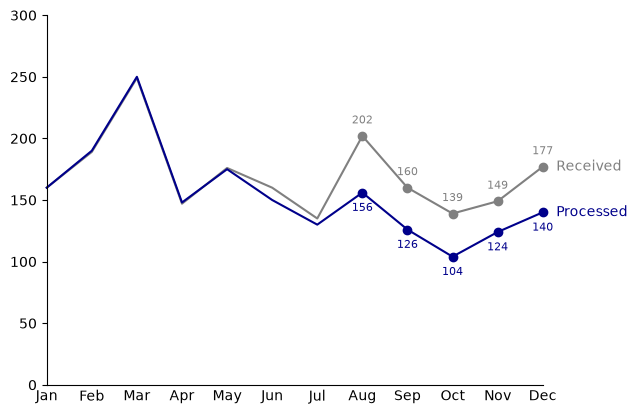

In [25]:
# Multiple Line Graph (Figure 5.8 on pg. 143)

# Data
x = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
y1 = [160, 189, 249, 147, 176, 160, 135, 202, 160, 139, 149, 177]
y2 = [160, 190, 250, 148, 175, 150, 130, 156, 126, 104, 124, 140]

# Use subplots to easily access the axes (ax) object
fig, ax = plt.subplots()

# Plotting multiple lines
line1, = plt.plot(x, y1, label='', color='gray', linestyle='-', marker='o', markevery=[7, 8, 9, 10, 11])
line2, = plt.plot(x, y2, label='', color='darkblue', linestyle='-', marker='o', markevery=[7, 8, 9, 10, 11])

# Prevent last marker from being cut in half
line1.set_clip_on(False)
line2.set_clip_on(False)

# Use the numeric index position (len(x) - 1) instead of the string name
last_index = len(x) - 1

# Force x-axis to start on y-axis and stop immediately after Dec
ax.set_xlim(left=0, right=last_index)

# Remove x-axis ticks
ax.tick_params(axis='x', length=0)

# Force y-axis to start at 0
ax.set_ylim(bottom=0)
ax.set_ylim(top=300)

ax.text(last_index + 0.3, y1[-1], 'Received', color='gray', va='center', ha='left', clip_on=False)
ax.text(last_index + 0.3, y2[-1], 'Processed', color='darkblue', va='center', ha='left', clip_on=False)

for i in range(7, len(x)):
    ax.text(i, y1[i] + 8, str(y1[i]), color='gray', ha='center', va='bottom', fontsize=8)
    ax.text(i, y2[i] - 8, str(y2[i]), color='darkblue', ha='center', va='top', fontsize=8)

# Customizations
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show plot
plt.show()